In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/images2.zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 100


Displaying the first 5 images:


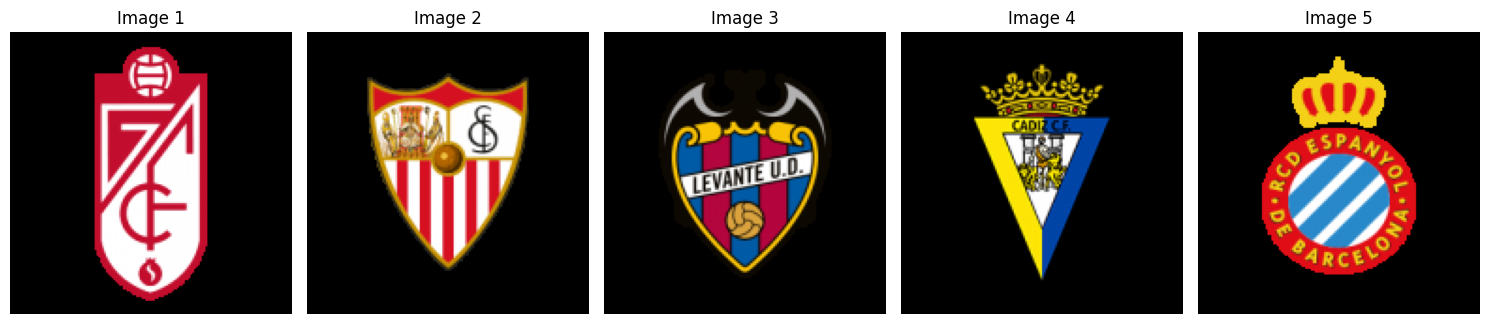

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {min(5, len(images))} images:")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

image_data = []
for idx, img in enumerate(images):
    height, width, channels = img.shape
    image_data.append({'Image_Index': idx, 'Height': height, 'Width': width, 'Channels': channels})

image_df = pd.DataFrame(image_data)
display(image_df.head())

,Image_Index,Height,Width,Channels
0,0,150,150,3
1,1,150,150,3
2,2,150,150,3
3,3,150,150,3
4,4,150,150,3


In [ ]:
resized_images = []
new_height, new_width = 224, 224

for img in images:
    resized_img = cv2.resize(img, (new_width, new_height))
    resized_images.append(resized_img)

images = resized_images

print(f"All images have been resized to {new_width}x{new_height} pixels.")

image_data_resized = []
for idx, img in enumerate(images):
    height, width, channels = img.shape
    image_data_resized.append({'Image_Index': idx, 'Height': height, 'Width': width, 'Channels': channels})

image_df_resized = pd.DataFrame(image_data_resized)
display(image_df_resized.head())

All images have been resized to 224x224 pixels.


,Image_Index,Height,Width,Channels
0,0,224,224,3
1,1,224,224,3
2,2,224,224,3
3,3,224,224,3
4,4,224,224,3


Displaying the first 5 resized images (224x224):


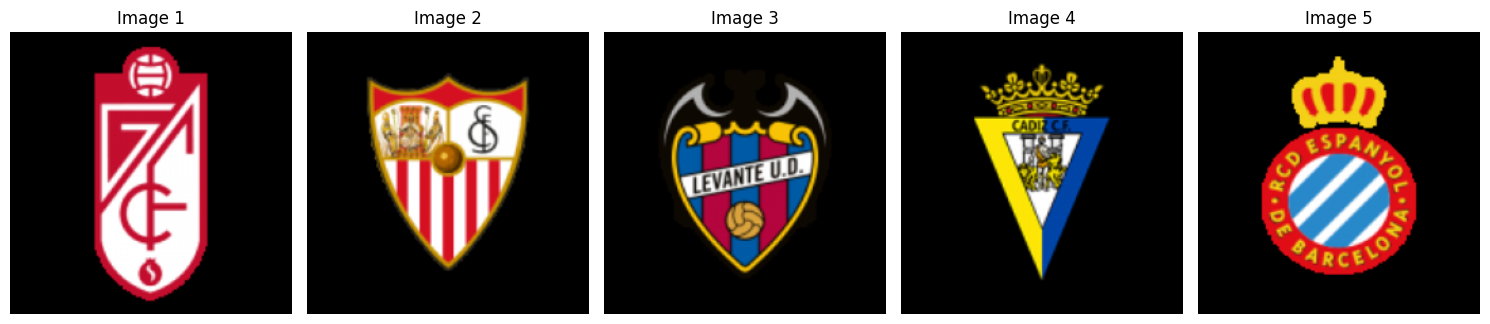

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {min(5, len(images))} resized images (224x224):")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(f'Image {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Convert Images to Grayscale

In [ ]:
gray_images = []

for img in images:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray_img)

print(f"All images have been converted to grayscale. Total: {len(gray_images)}")

All images have been converted to grayscale. Total: 100


Displaying the first 5 grayscale images:


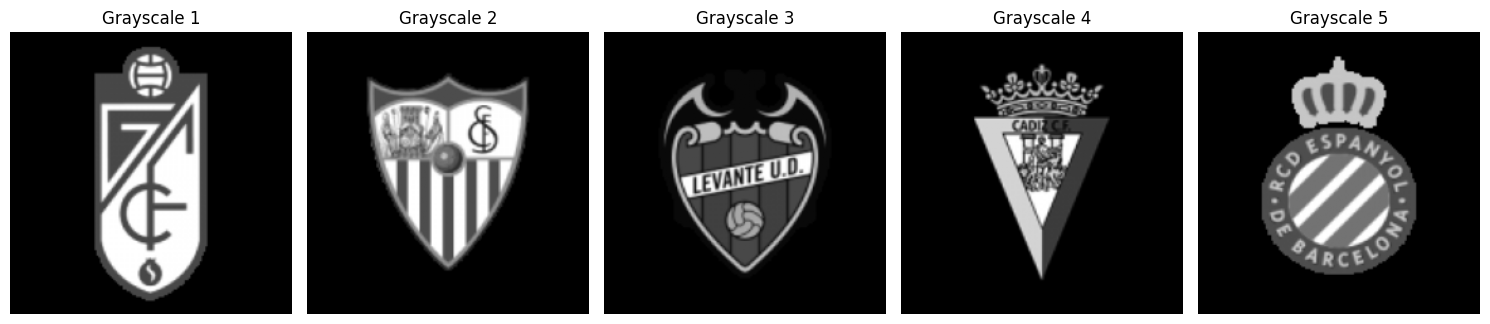

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {min(5, len(gray_images))} grayscale images:")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(gray_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(gray_images[i], cmap='gray')
    plt.title(f'Grayscale {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Convert Images to RGB

In [ ]:
rgb_images = []

for img in images:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)

print(f"All images have been converted to RGB. Total: {len(rgb_images)}")

All images have been converted to RGB. Total: 100


Displaying the first 5 RGB images:


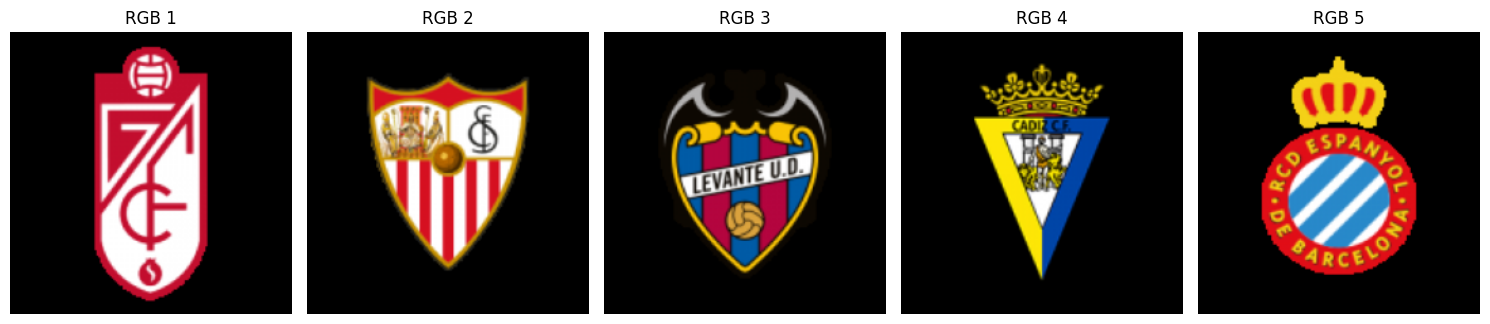

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {min(5, len(rgb_images))} RGB images:")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(rgb_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(rgb_images[i])
    plt.title(f'RGB {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Convert Images to HSV

In [ ]:
hsv_images = []

for img in images:
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv_img)

print(f"All images have been converted to HSV. Total: {len(hsv_images)}")

All images have been converted to HSV. Total: 100


Displaying the first 5 HSV images (converted to RGB for display):


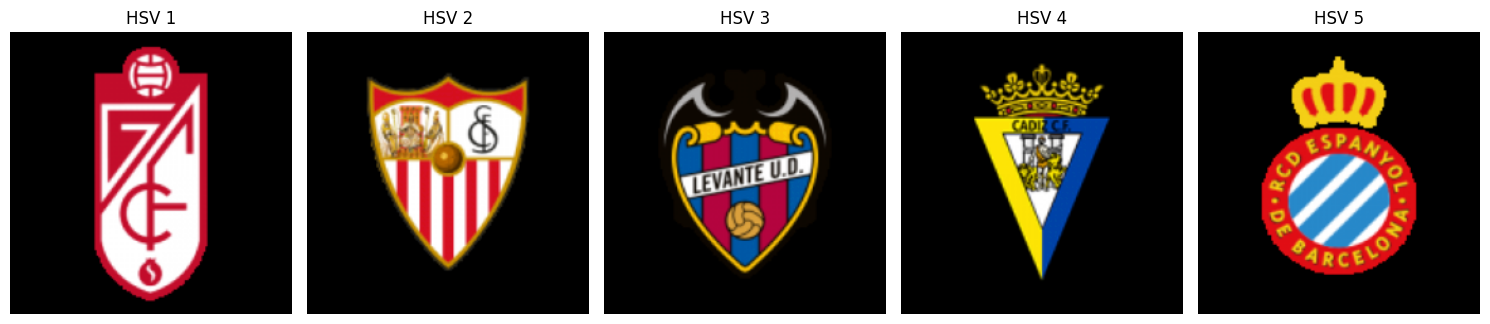

In [ ]:
import matplotlib.pyplot as plt

# Display the first 5 HSV images (note: matplotlib will display HSV as RGB if not explicitly converted)
print(f"Displaying the first {min(5, len(hsv_images))} HSV images (converted to RGB for display):")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(hsv_images))):
    plt.subplot(1, 5, i + 1)

    display_img_rgb = cv2.cvtColor(hsv_images[i], cv2.COLOR_HSV2BGR)
    display_img_rgb = cv2.cvtColor(display_img_rgb, cv2.COLOR_BGR2RGB)
    plt.imshow(display_img_rgb)
    plt.title(f'HSV {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Normalize Pixel Values for Main `images` List (BGR)

In [ ]:
import numpy as np


images = [img.astype(np.float32) / 255.0 for img in images]
print(f"Main 'images' list (BGR) normalized. Example pixel value range: {images[0].min():.2f} - {images[0].max():.2f}")

Main 'images' list (BGR) normalized. Example pixel value range: 0.00 - 1.00


### Displaying First 5 Normalized BGR Images (Converted to RGB for Display)

Displaying the first 5 normalized BGR images (converted to RGB for display):


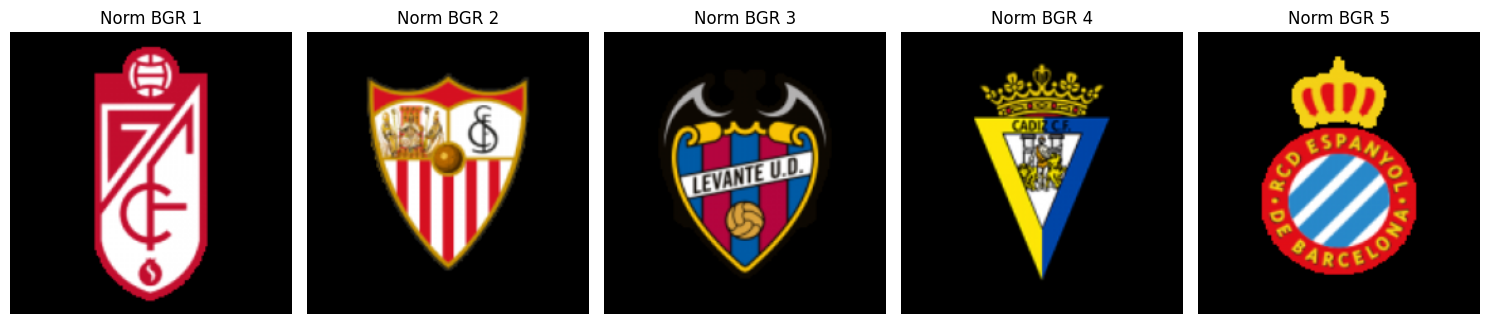

In [ ]:
import matplotlib.pyplot as plt

print(f"Displaying the first {min(5, len(images))} normalized BGR images (converted to RGB for display):")

plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(f'Norm BGR {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Data Augmentation

### 1. Rotation Augmentation

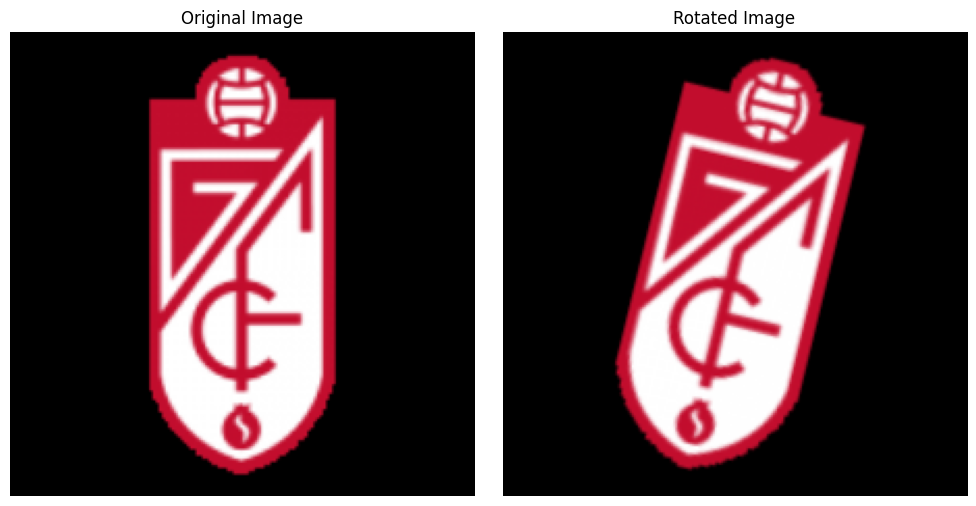

In [ ]:
import random
import numpy as np

def random_rotation(image, angle_range=(-15, 15)):
    angle = random.uniform(angle_range[0], angle_range[1])
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    return rotated_image

# Demonstrate rotation
sample_image = images[0]
rotated_sample = random_rotation(sample_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(rotated_sample, cv2.COLOR_BGR2RGB))
plt.title('Rotated Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Flip Augmentation

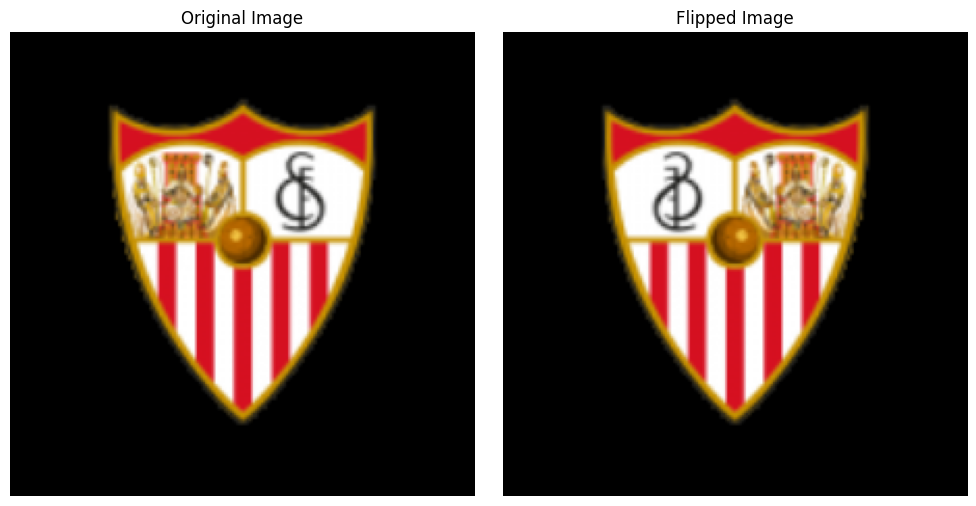

In [ ]:
import random

def random_flip(image):
    flip_code = random.choice([-1, 0, 1]) # -1: both, 0: vertical, 1: horizontal
    flipped_image = cv2.flip(image, flip_code)
    return flipped_image

# Demonstrate flip
sample_image = images[1] # Use a different sample for variety
flipped_sample = random_flip(sample_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)) # Convert back to RGB for matplotlib
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(flipped_sample, cv2.COLOR_BGR2RGB)) # Convert back to RGB for matplotlib
plt.title('Flipped Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Zoom Augmentation

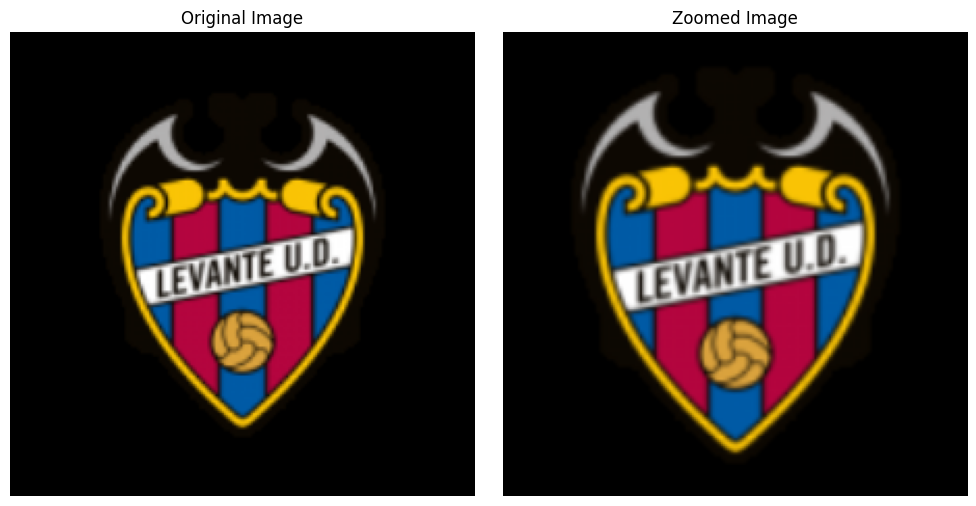

In [ ]:
import random

def random_zoom(image, zoom_range=(0.8, 1.2)):
    zoom_factor = random.uniform(zoom_range[0], zoom_range[1])
    h, w = image.shape[:2]

    # Calculate new dimensions
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

    # Resize the image
    resized_image = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # Crop or pad to original size
    if zoom_factor > 1.0: # Zoom in, so crop
        start_h = new_h // 2 - h // 2
        start_w = new_w // 2 - w // 2
        zoomed_image = resized_image[start_h:start_h + h, start_w:start_w + w]
    else: # Zoom out, so pad
        zoomed_image = np.zeros_like(image)
        insert_h = h // 2 - new_h // 2
        insert_w = w // 2 - new_w // 2
        zoomed_image[insert_h:insert_h + new_h, insert_w:insert_w + new_w] = resized_image

    return zoomed_image

# Demonstrate zoom
sample_image = images[2] # Another sample image
zoomed_sample = random_zoom(sample_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(zoomed_sample, cv2.COLOR_BGR2RGB))
plt.title('Zoomed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Brightness Adjustment Augmentation

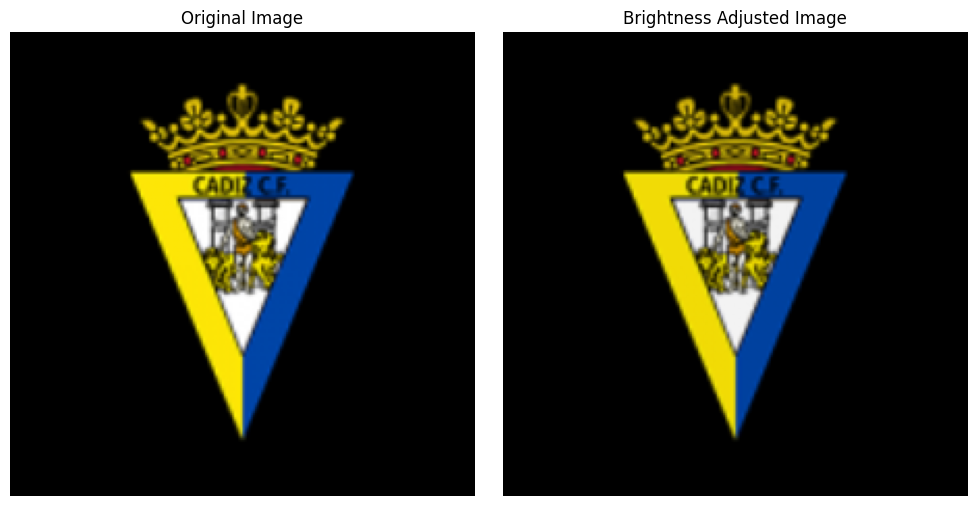

In [ ]:
import random

def random_brightness(image, brightness_range=(0.7, 1.3)):
    factor = random.uniform(brightness_range[0], brightness_range[1])
    adjusted_image = image * factor
    adjusted_image = np.clip(adjusted_image, 0.0, 1.0) # Clip to 0-1 range after adjustment
    return adjusted_image

# Demonstrate brightness adjustment
sample_image = images[3] # Another sample image
brightness_sample = random_brightness(sample_image)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(brightness_sample, cv2.COLOR_BGR2RGB))
plt.title('Brightness Adjusted Image')
plt.axis('off')

plt.tight_layout()
plt.show()

## Reusable Image Preprocessing Function

In [ ]:
def preprocess_image(image_path, target_size=(224, 224), normalize=True):
    """
    Loads an image, resizes it, and optionally normalizes its pixel values.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired (width, height) for the image.
        normalize (bool): If True, normalize pixel values from 0-255 to 0-1.

    Returns:
        numpy.ndarray: The preprocessed image.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Resize the image
    img = cv2.resize(img, target_size)

    # Normalize pixel values if requested
    if normalize:
        img = img.astype(np.float32) / 255.0

    return img

print("Preprocessing function 'preprocess_image' defined.")

Preprocessing function 'preprocess_image' defined.


### Demonstration of the Preprocessing Function

Using sample image: extracted_images/top-5-football-leagues/la-liga/granada.png
Processed image shape: (224, 224, 3)
Processed image pixel range: 0.00 - 1.00


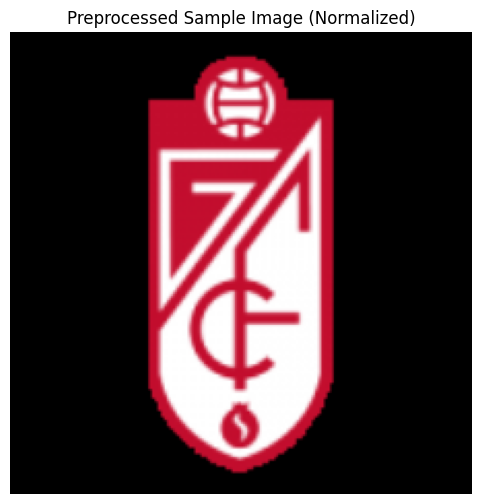

In [ ]:

import os

sample_image_path = None
for root, dirs, files in os.walk('extracted_images'):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            sample_image_path = os.path.join(root, file)
            break
    if sample_image_path:
        break

if sample_image_path:
    print(f"Using sample image: {sample_image_path}")
    processed_sample_image = preprocess_image(sample_image_path, target_size=(224, 224), normalize=True)

    print(f"Processed image shape: {processed_sample_image.shape}")
    print(f"Processed image pixel range: {processed_sample_image.min():.2f} - {processed_sample_image.max():.2f}")

    # Display the processed image
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(processed_sample_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title('Preprocessed Sample Image (Normalized)')
    plt.axis('off')
    plt.show()
else:
    print("Could not find a sample image to demonstrate preprocessing.")